In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from src.optimizer import ParameterOptimizer

In [3]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

In [4]:
optimizer = ParameterOptimizer()

In [5]:
lookbacks = [1,2,4,8,13,26]

In [6]:
results = optimizer.optimize_lookback(
    prices,
    lookbacks
)

Running lookback = 1
Running lookback = 2
Running lookback = 4
Running lookback = 8
Running lookback = 13
Running lookback = 26


In [7]:
results

,Lookback,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Win Rate
0,13,0.051761,0.306424,0.168920,-0.541531,0.518328
1,8,0.048425,0.316237,0.153127,-0.649232,0.517595
2,4,0.016620,0.318687,0.052152,-0.835194,0.516862
3,26,0.005184,0.309390,0.016755,-0.857103,0.505132
4,1,-0.085392,0.321788,-0.265367,-0.970512,0.497067
5,2,-0.120878,0.317531,-0.380682,-0.981564,0.482405


In [8]:
best = results.iloc[0]

print(best)

Lookback             13.000000
Annual Return         0.051761
Annual Volatility     0.306424
Sharpe                0.168920
Max Drawdown         -0.541531
Win Rate              0.518328
Name: 0, dtype: float64


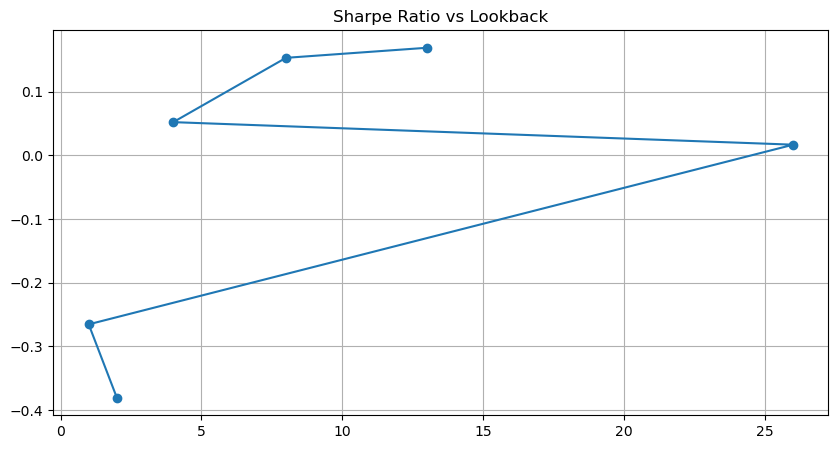

In [9]:
charts_dir = Path("../results/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,5))

plt.plot(
    results["Lookback"],
    results["Sharpe"],
    marker="o"
)

plt.title("Sharpe Ratio vs Lookback")

plt.grid(True)

plt.savefig(
    charts_dir/"sharpe_vs_lookback.png",
    dpi=300
)

plt.show()

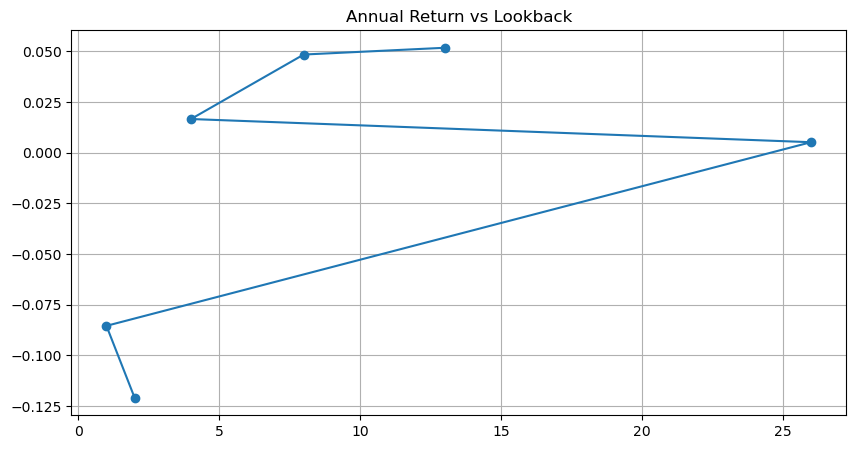

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    results["Lookback"],
    results["Annual Return"],
    marker="o"
)

plt.title("Annual Return vs Lookback")

plt.grid(True)

plt.savefig(
    charts_dir/"annual_return_vs_lookback.png",
    dpi=300
)

plt.show()

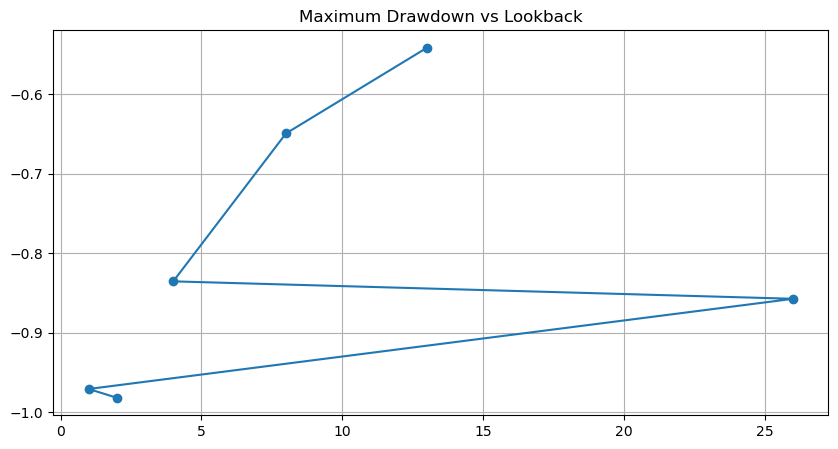

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    results["Lookback"],
    results["Max Drawdown"],
    marker="o"
)

plt.title("Maximum Drawdown vs Lookback")

plt.grid(True)

plt.savefig(
    charts_dir/"drawdown_vs_lookback.png",
    dpi=300
)

plt.show()

In [12]:
results_dir = Path("../results")
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

results.to_csv(
    results_dir/"lookback_optimization.csv",
    index=False
)

In [13]:
reports_dir = Path("../results/reports")
reports_dir.mkdir(
    parents=True,
    exist_ok=True
)

best = results.iloc[0]

report = f"""
====================================================
PARAMETER OPTIMIZATION REPORT
====================================================

Best Lookback        : {best['Lookback']} Weeks

Annual Return        : {best['Annual Return']:.2%}

Annual Volatility    : {best['Annual Volatility']:.2%}

Sharpe Ratio         : {best['Sharpe']:.3f}

Maximum Drawdown     : {best['Max Drawdown']:.2%}

Winning Weeks        : {best['Win Rate']:.2%}
"""

print(report)

with open(
    reports_dir/"optimization_summary.txt",
    "w"
) as f:
    f.write(report)


PARAMETER OPTIMIZATION REPORT

Best Lookback        : 13.0 Weeks

Annual Return        : 5.18%

Annual Volatility    : 30.64%

Sharpe Ratio         : 0.169

Maximum Drawdown     : -54.15%

Winning Weeks        : 51.83%



# Interpretation

## Best Parameter

The optimizer selected a 13-week lookback as the best-performing momentum parameter based on the Sharpe ratio.

## Observations

- Longer lookback windows outperformed shorter windows.
- The strategy remains highly concentrated because it holds only one long and one short position.
- Future improvements include:
  - Top-N portfolio construction
  - Transaction cost modelling
  - Volatility scaling
  - Sector neutrality